<a href="https://colab.research.google.com/github/DanieleBaiocco/nlp_first_assignment/blob/main/Assignment1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 1

## Dataset preparation

In [47]:
import os
from urllib import request
from zipfile import ZipFile
import numpy as np
import pandas as pd
import sys

import gensim
import pickle
import gensim.downloader as gloader

import copy

from sklearn.preprocessing import LabelBinarizer

In [48]:
class Dataset():

    def __init__(
        self,
        url,
        preprocessing = True,
        download_folder = "Datasets"
    ):

      self.download_extract_dataset(download_folder, url)
      self.train_list, self.val_list, self.test_list = self.build_splitted_list(download_folder, preprocessing)
      self.max_sentence_size = self.get_max_sentence_size()

    def download_extract_dataset(self, download_folder: str, url: str):
        dataset_folder = os.path.join(os.getcwd(), download_folder)
        dataset_path = os.path.join(dataset_folder, "Corpora.zip")
        if not os.path.exists(dataset_folder):
          os.makedirs(dataset_folder)
        if not os.path.exists(dataset_path):
            print("Downloading and Extracting dataset...")
            request.urlretrieve(url, dataset_path)
            with ZipFile(dataset_path, 'r') as zObject:
                zObject.extractall(
            path=dataset_folder)
            print("Done!")

    def build_splitted_list(self, download_folder: str, preprocessing: bool):
        df_rows = []

        train_list = []
        val_list = []
        test_list = []

        dataset_folder = os.path.join(os.getcwd(), download_folder, "dependency_treebank")
        list_dir = os.listdir(dataset_folder)
        list_dir.sort()

        doc_number = 1
        doc_classification = self.doc_classification(doc_number)
        
        for dir in list_dir:
            file_path = os.path.join(dataset_folder, dir)               
            if os.path.isfile(file_path):
                with open(file_path, mode = 'r', encoding = 'utf-8') as text_file:
                  critical_line = 0
                  df_row = []
                  lines = text_file.readlines()
                  for count, line in enumerate(lines):
                      splitted_line = line.split()
                      if len(splitted_line) != 3 or count + 1 >= len(lines):
                          if doc_classification == 'train':
                              train_list.append(df_row)
                          elif doc_classification == 'val':
                              val_list.append(df_row)
                          elif doc_classification == 'test':
                              test_list.append(df_row)
                          df_row = []
                          critical_line = count + 1
                          if count + 1 >= len(lines):
                              doc_number += 1
                      else:
                        if count == critical_line:
                            doc_classification = self.doc_classification(doc_number)
                        df_row.append(
                            (self.preprocessing(splitted_line[0]) if preprocessing else splitted_line[0], 
                             splitted_line[1])
                            )

        return train_list, val_list, test_list

    def doc_classification(self, doc_number):
        if doc_number <= 100:
            split = 'train'
        elif 100 < doc_number <=150:
            split= 'val'
        else: 
            split = 'test'
        return split 
    
    def preprocessing(self, word):
        wordtr = ""
        splitted_word = word.split('-')
        if len(splitted_word) > 1:
          wordtr = splitted_word[1]
        else: wordtr = splitted_word[0]
        #try:
        #    float(wordtr)
        #    wordtr = '36'
        #except ValueError:
        #   pass
        return wordtr.lower()
    
    def get_max_sentence_size(self):
        return max([len(x) for x in self.train_list + self.val_list + self.test_list])

In [49]:
url = "https://raw.githubusercontent.com/nltk/nltk_data/gh-pages/packages/corpora/dependency_treebank.zip"
data = Dataset(url = url)

## Data Analysis 

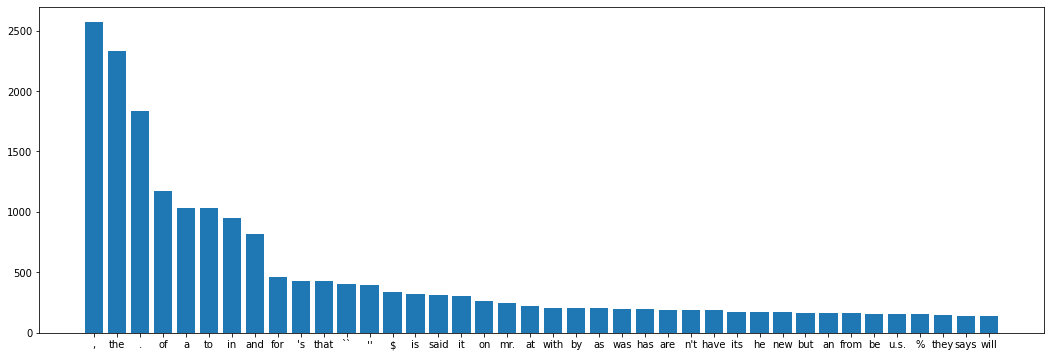

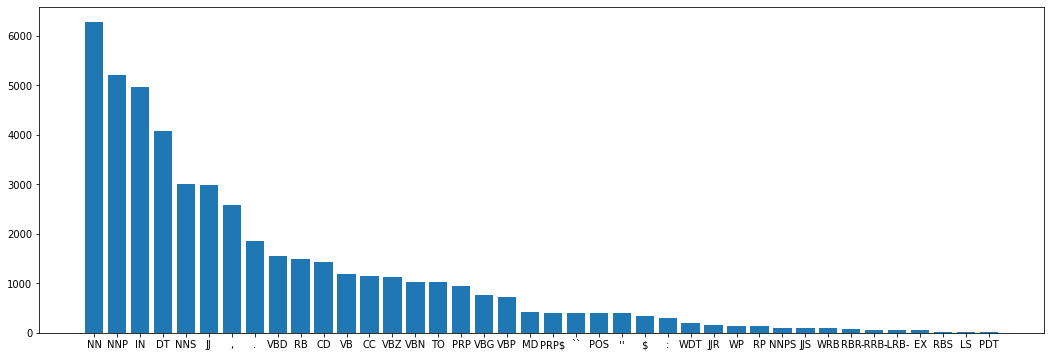

In [50]:
from collections import Counter
from collections import defaultdict
import seaborn as sns
import matplotlib.pyplot as plt

def create_corpus(data):
    words = []
    labels = []
    for sentence in data:
        for word in sentence:
            words.append(word[0])
            labels.append(word[1])
    return words, labels

words, labels = create_corpus(data.train_list)

def plot_counts(data, results_num: int):
    dic=defaultdict(int)
    for word in data:
        dic[word]+=1

    top=sorted(dic.items(), key=lambda x:x[1],reverse=True)[:results_num] 
    figure = plt.figure()
    plt.rcParams['figure.figsize'] = (18.0, 6.0)
    plt.xlabel = 'Words'
    plt.ylabel = 'Count of occurencies in dataset'
    x,y=zip(*top)
    plt.bar(x,y, label = 'Count of occurencies in dataset')
    figure.show()

plot_counts(words, 40)
plot_counts(labels, 40)

In [51]:
class Embedder():
  
    def __init__(
        self,
        data: Dataset,
        embedding_dimension = 100,
    ):
        self.embedding_model = self.load_embedding_model(embedding_dimension)
        self.embedding_dimension = embedding_dimension
        
        v1 = self.embedding_model
        oov_terms_train = self.check_OOV_terms(v1, data.train_list, "1")
        v2 = self.add_OOV_terms(v1, oov_terms_train, embedding_dimension)
        oov_terms_val = self.check_OOV_terms(v2, data.val_list, "2")
        v3 = self.add_OOV_terms(v2, oov_terms_val, embedding_dimension)
        oov_terms_test = self.check_OOV_terms(v3, data.test_list, "3")
        v4 = self.add_OOV_terms(v3, oov_terms_test, embedding_dimension)

        print(1)
        enc_X_train, y_train = self.build_embeddings_df(v2, data.train_list, embedding_dimension, data.max_sentence_size)
        enc_X_val, y_val = self.build_embeddings_df(v3, data.val_list, embedding_dimension, data.max_sentence_size)
        enc_X_test, y_test = self.build_embeddings_df(v4, data.test_list, embedding_dimension, data.max_sentence_size)

        print(2)
        self.encoder = LabelBinarizer()
        enc_y_train = self.one_hot_encode(y_train, data.max_sentence_size, is_fit = True)
        enc_y_val = self.one_hot_encode(y_val, data.max_sentence_size)
        enc_y_test = self.one_hot_encode(y_test, data.max_sentence_size)

        self.X_train = enc_X_train
        self.X_val = enc_X_val
        self.X_test = enc_X_test
        self.y_train = enc_y_train
        self.y_val = enc_y_val
        self.y_test = enc_y_test

    def load_embedding_model(self, embedding_dimension = 100):
        loading_dir_path = os.path.join(os.getcwd(), "embedding_model")
        loading_model_path = os.path.join(loading_dir_path, "model.bin")
        download_path = "glove-wiki-gigaword-{}".format(embedding_dimension)
        emb_model = gloader.load(download_path)
        return emb_model 

    def check_OOV_terms(self, vocabulary, dataset, v_num):
        embedding_vocabulary = set(vocabulary.vocab.keys())
        word_listing = set()
        for sentence in dataset:
          for couple in sentence:
            word, _ = couple
            word_listing.add(word)
        oov = word_listing.difference(embedding_vocabulary)

        oov_percentage = float(len(list(oov))) * 100 / len(word_listing)
        print(f"Total OOV terms in V{v_num}: {len(list(oov))} ({oov_percentage:.2f}%)")
        return list(oov)

    def add_OOV_terms(self, vocabulary, oov, embedding_dim):
        voc = copy.deepcopy(vocabulary)
        for word in oov:
          voc[word] = np.random.uniform(-1, 1, size=embedding_dim)
        print(f"Generated embeddings for {len(oov)} OOV words.")
        return voc

    def build_embeddings_df(self, vocabulary, df, embedding_dimension, max_sentence_size):
        df_rows = []
        ys = []
        for sentence in df:
          embeddings_row = np.array([vocabulary[word] for word, _ in sentence])
          df_rows.append(
              np.vstack(
                  (
                  embeddings_row,
                  np.zeros((max_sentence_size - len(sentence), embedding_dimension)),
                  )
              )
          )
          y = [target for _, target in sentence]
          ys.append(y)

        
        return np.array(df_rows), np.array(ys)

    def one_hot_encode(self, y, max_sentence_size, is_fit = False):
        y_onehot = []

        if is_fit:
          self.encoder.fit([word for sentence in y for word in sentence])

        for sentence in y:
          y_onehot_row = self.encoder.transform(sentence)
          padding_row = np.zeros((max_sentence_size - len(y_onehot_row), len(self.encoder.classes_)))
          y_onehot.append(
              np.vstack(
                  ( 
                    y_onehot_row,
                    padding_row,  
                  )
              )
          )
        return np.array(y_onehot)

In [52]:
embedded_data = Embedder(data)

Total OOV terms in V1: 157 (2.22%)
Generated embeddings for 157 OOV words.
Total OOV terms in V2: 81 (1.55%)
Generated embeddings for 81 OOV words.
Total OOV terms in V3: 68 (2.07%)
Generated embeddings for 68 OOV words.
1


/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:81: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.


2


In [53]:
from keras import Sequential, Input, optimizers
from keras.layers import Dense, Bidirectional, LSTM, Activation, TimeDistributed, Embedding, Masking, GlobalMaxPool1D, BatchNormalization, Dropout
from keras.callbacks import EarlyStopping

embedding_dimension = 100

input_shape = (data.max_sentence_size, embedding_dimension)

def baseline_model(input_shape, classes_num):
    model = Sequential()
    model.add(Masking(mask_value=0, input_shape=input_shape))
    model.add(Bidirectional(LSTM(64, return_sequences = True, dropout=0.2, recurrent_dropout=0.2)))
    model.add(TimeDistributed(Dense(classes_num, activation = 'softmax')))
    model.compile(loss='categorical_crossentropy', optimizer = optimizers.Adam(), metrics=["accuracy"])
    return model

def strong_baseline(input_shape, classes_num):
    model = Sequential()
    model.add(Masking())
    model.add(Bidirectional(LSTM(64, return_sequences = True, recurrent_dropout=0.2), input_shape = input_shape))
    model.add(Dropout(0.5))
    model.add(TimeDistributed(Dense(input_shape[0], activation = "relu")))
    model.add(Dropout(0.5))
    model.add(TimeDistributed(Dense(input_shape[0], activation = "relu")))
    model.add(Dropout(0.5))
    model.add(TimeDistributed(Dense(classes_num)))
    model.add(Activation('softmax'))
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

In [54]:
model = baseline_model(input_shape, 45)

In [55]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 masking_1 (Masking)         (None, 249, 100)          0         
                                                                 
 bidirectional_1 (Bidirectio  (None, 249, 128)         84480     
 nal)                                                            
                                                                 
 time_distributed_1 (TimeDis  (None, 249, 45)          5805      
 tributed)                                                       
                                                                 
Total params: 90,285
Trainable params: 90,285
Non-trainable params: 0
_________________________________________________________________


In [56]:
cb_early_stopping = EarlyStopping(
    monitor='val_accuracy',
    min_delta=0.05,
    patience=3,
    restore_best_weights=True
)

history = model.fit(embedded_data.X_train, embedded_data.y_train, batch_size=32, epochs=30, validation_data=(embedded_data.X_val, embedded_data.y_val), callbacks=[cb_early_stopping])

Epoch 1/30
62/62 [==============================] - 119s 2s/step - loss: 0.2667 - accuracy: 0.3029 - val_loss: 0.1970 - val_accuracy: 0.5088
Epoch 2/30
62/62 [==============================] - 114s 2s/step - loss: 0.1531 - accuracy: 0.6075 - val_loss: 0.1140 - val_accuracy: 0.7037
Epoch 3/30
62/62 [==============================] - 114s 2s/step - loss: 0.0999 - accuracy: 0.7420 - val_loss: 0.0839 - val_accuracy: 0.7720
Epoch 4/30
62/62 [==============================] - 113s 2s/step - loss: 0.0783 - accuracy: 0.7889 - val_loss: 0.0691 - val_accuracy: 0.8102
Epoch 5/30
62/62 [==============================] - 114s 2s/step - loss: 0.0666 - accuracy: 0.8190 - val_loss: 0.0599 - val_accuracy: 0.8368
Epoch 6/30
62/62 [==============================] - 114s 2s/step - loss: 0.0592 - accuracy: 0.8371 - val_loss: 0.0541 - val_accuracy: 0.8482
Epoch 7/30
62/62 [==============================] - 112s 2s/step - loss: 0.0542 - accuracy: 0.8480 - val_loss: 0.0498 - val_accuracy: 0.8569
Epoch 8/30
62

In [64]:
import matplotlib.pyplot as plt

def plot_history(model_history,keys):
    m,val_m = keys
    plt.plot(model_history.history[m])
    plt.plot(model_history.history[val_m])
    # plt.ylabel(m)
    # plt.xlabel('epoch')
    plt.legend(['train', 'validation'], loc='upper left')
    plt.show()


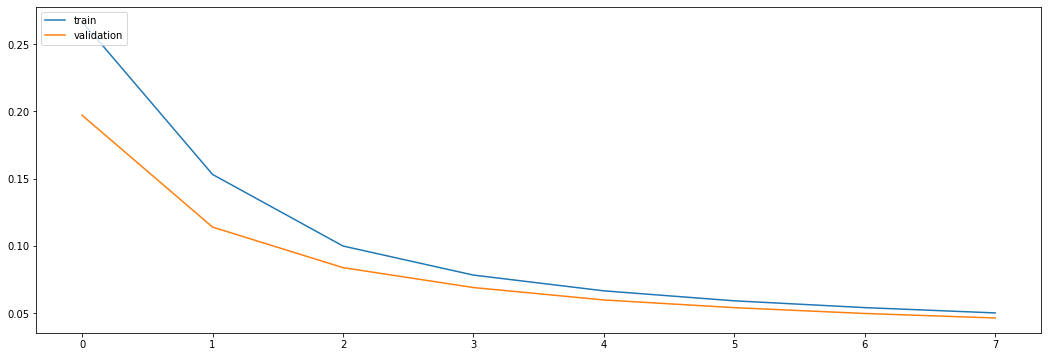

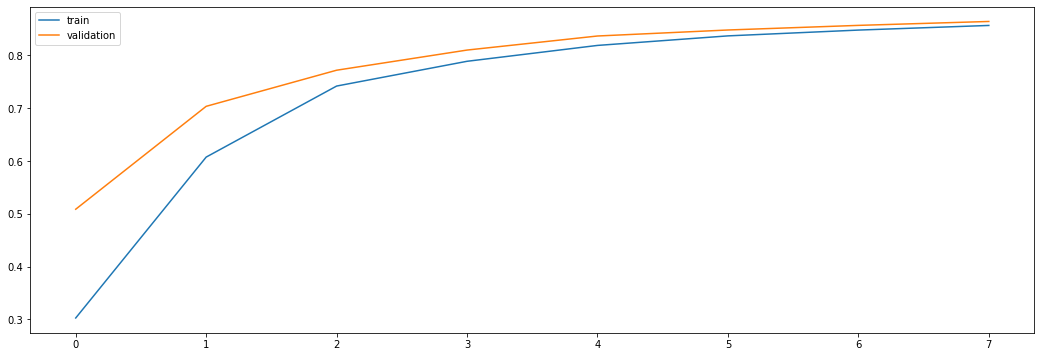

In [65]:
#baseline
plot_history(history, ['loss','val_loss'])
plot_history(history, ['accuracy','val_accuracy'])

In [66]:
from sklearn.metrics import f1_score

y_true = embedded_data.y_test
y_pred = model.predict(embedded_data.X_test)

21/21 [==============================] - 3s 142ms/step


In [67]:
#  MODIFICARE NOMI

def prob_to_onehot(predictions):
  for sentence in predictions:
    for tag in sentence:
      max = np.argmax(np.array(tag))
      tag[max] = 1
      tag[tag!=1] = 0
  return predictions

def cut(y):
  y_cut = []
  for i, sentence in enumerate(data.test_list):
      y_cut.append(y[i][0:len(sentence)])
  return y_cut

def inverseTransform(y):
  y_cut = []
  for i in range(len(data.test_list)):
      y_cut.append(embedded_data.encoder.inverse_transform(y[i]))
  return y_cut

def remove_symbols():
  symbs = ['#', '$', "''", ',', '-LRB-', '-RRB-', '.', ':', 'LS', '``']
  labels = list(embedded_data.encoder.classes_)
  for sym in symbs:
    labels.remove(sym)
  return labels

true_labels = remove_symbols()
y_pred_oh = prob_to_onehot(y_pred)

In [68]:
y_true_trans = np.array(inverseTransform(y_true))
y_pred_trans = np.array(inverseTransform(y_pred_oh))

**F1-score deve essere calcolato su le liste trasformate: da one hot encoding a string tags**

In [69]:
f1_score(y_true_trans.flatten(), y_pred_trans.flatten(), labels = true_labels, average='macro', zero_division=0)

0.5465169032863192

**La funzione cut rimuove il padding, riportando gli array alla dimensione della frase originale**

In [70]:
y_pred_trans_cut = cut(y_pred_trans)
y_true_trans_cut = cut(y_true_trans)

print("Sentence: {}".format(data.test_list[0]))
print("True tags: {}".format(y_true_trans_cut[0]))
print("Predicted tags: {}".format(y_pred_trans_cut[0]))

Sentence: [('intelogic', 'NNP'), ('trace', 'NNP'), ('inc.', 'NNP'), (',', ','), ('san', 'NNP'), ('antonio', 'NNP'), (',', ','), ('texas', 'NNP'), (',', ','), ('said', 'VBD'), ('it', 'PRP'), ('bought', 'VBD'), ('2.7', 'CD'), ('million', 'CD'), ('shares', 'NNS'), (',', ','), ('or', 'CC'), ('about', 'IN'), ('18', 'CD'), ('%', 'NN'), (',', ','), ('of', 'IN'), ('its', 'PRP$'), ('common', 'JJ'), ('stock', 'NN'), ('from', 'IN'), ('an', 'DT'), ('unaffiliated', 'JJ'), ('shareholder', 'NN'), ('for', 'IN'), ('$', '$'), ('3.625', 'CD'), ('a', 'DT'), ('share', 'NN'), (',', ','), ('or', 'CC'), ('$', '$'), ('9.9', 'CD'), ('million', 'CD'), ('.', '.')]
True tags: ['NNP' 'NNP' 'NNP' ',' 'NNP' 'NNP' ',' 'NNP' ',' 'VBD' 'PRP' 'VBD' 'CD'
 'CD' 'NNS' ',' 'CC' 'IN' 'CD' 'NN' ',' 'IN' 'PRP$' 'JJ' 'NN' 'IN' 'DT'
 'JJ' 'NN' 'IN' '$' 'CD' 'DT' 'NN' ',' 'CC' '$' 'CD' 'CD' '.']
Predicted tags: ['NNP' 'NNP' 'NNP' ',' 'NNP' 'NNP' ',' 'NNP' ',' 'VBD' 'PRP' 'VBD' 'CD'
 'CD' 'NNS' ',' 'CC' 'IN' 'CD' 'NN' ',' 'IN' 'PRP

In [ ]:
# import necessary libraries
import warnings
warnings.filterwarnings("ignore")

import numpy as np
from typing import List, Dict
import pandas as pd
from tqdm import tqdm
from matplotlib import pyplot as plt
import nltk

import seaborn as sns

from gensim.models import KeyedVectors

from keras.utils import pad_sequences
from keras.utils.np_utils import to_categorical
from keras.models import Sequential
from keras.layers import Embedding
from keras.layers import Dense, Input
from keras.layers import TimeDistributed
from keras.layers import LSTM, GRU, Bidirectional, SimpleRNN, RNN
from keras.models import Model
from keras.preprocessing.text import Tokenizer

from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle

In [ ]:
import os
from urllib import request
from zipfile import ZipFile
import numpy as np
import pandas as pd

print(f"Current work directory: {os.getcwd()}")
dataset_folder = os.path.join(os.getcwd(), "Datasets")

if not os.path.exists(dataset_folder):
    os.makedirs(dataset_folder)

url = "https://raw.githubusercontent.com/nltk/nltk_data/gh-pages/packages/corpora/dependency_treebank.zip"
dataset_path = os.path.join(dataset_folder, "Corpora.zip")
print(dataset_path)

def download_dataset(download_path: str, url: str):
    if not os.path.exists(download_path):
        print("Downloading dataset...")
        request.urlretrieve(url, download_path)
        print("Download complete!")

def extract_dataset(download_path: str, extract_path: str):
    print("Extracting dataset... (it may take a while...)")
    with ZipFile(download_path, 'r') as zObject:
        zObject.extractall(
		path=extract_path)
    print("Extraction completed!")

download_dataset(dataset_path, url)
extract_dataset(dataset_path, dataset_folder)

Current work directory: /content
/content/Datasets/Corpora.zip
Extracting dataset... (it may take a while...)
Extraction completed!


In [ ]:
def split_sentences(end) -> pd.DataFrame:
    dataset_folder = os.path.join(os.getcwd(), "Datasets", "dependency_treebank")
    list_dir = os.listdir(dataset_folder) 
    dataframe_rows = []
    count = 0 
    for dir in range(end):
      file_path = os.path.join(dataset_folder, list_dir[dir])   
      if dir == 0 or dir==1:
        print(file_path)               
      try:
        if os.path.isfile(file_path):
          with open(file_path, mode = 'r', encoding = 'utf-8') as text_file:
            collected_lines = []
            for line in text_file:
              if len(line) == 1:
                count = count + 1
      except Exception as e:
            print('Failed to process %s. Reason: %s' % (file_path, e))
            sys.exit(0)
    print(count)
    return count

In [ ]:
def read_sentence():
    dataset_folder = os.path.join(os.getcwd(), "Datasets", "dependency_treebank")
    list_dir = os.listdir(dataset_folder) 
    list_dir.sort()

    document = []
    documents = []
    sentence = []
    document_count = 0
    for dir in list_dir:
      file_path = os.path.join(dataset_folder, dir)               
      try:
          if os.path.isfile(file_path):
            with open(file_path, mode = 'r', encoding = 'utf-8') as text_file:
              document = []
              lines = text_file.readlines()
              for count, line in enumerate(lines):
                splitted_line = line.split()
                if len(splitted_line) == 3:
                  sentence.append((splitted_line[0], splitted_line[1]))
                if (len(splitted_line) != 3 or count + 1 >= len(lines)):
                  document.append(sentence)
                  sentence = []
              documents.append(document)
      except Exception as e:
            print('Failed to process %s. Reason: %s' % (file_path, e))
            sys.exit(0)
    return pd.DataFrame(documents)

documents = read_sentence()

In [ ]:
documents.iloc[:3]

,0,1,2,3,4,5,6,7,8,9,...,175,176,177,178,179,180,181,182,183,184
0,"[(Pierre, NNP), (Vinken, NNP), (,, ,), (61, CD...","[(Mr., NNP), (Vinken, NNP), (is, VBZ), (chairm...",None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
1,"[(Rudolph, NNP), (Agnew, NNP), (,, ,), (55, CD...",None,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
2,"[(A, DT), (form, NN), (of, IN), (asbestos, NN)...","[(The, DT), (asbestos, NN), (fiber, NN), (,, ,...","[(Lorillard, NNP), (Inc., NNP), (,, ,), (the, ...","[(Although, IN), (preliminary, JJ), (findings,...","[(A, DT), (Lorillard, NNP), (spokewoman, NN), ...","[(We, PRP), ('re, VBP), (talking, VBG), (about...","[(There, EX), (is, VBZ), (no, DT), (asbestos, ...","[(Neither, DT), (Lorillard, NNP), (nor, CC), (...","[(``, ``), (We, PRP), (have, VBP), (no, DT), (...","[(Dr., NNP), (Talcott, NNP), (led, VBD), (a, D...",...,None,None,None,None,None,None,None,None,None,None


In [ ]:
train_set = documents[:100]
val_set = documents[100:150]
test_set = documents[150:]

In [ ]:
train_set.iloc[0][1]

[('Mr.', 'NNP'),
 ('Vinken', 'NNP'),
 ('is', 'VBZ'),
 ('chairman', 'NN'),
 ('of', 'IN'),
 ('Elsevier', 'NNP'),
 ('N.V.', 'NNP'),
 (',', ','),
 ('the', 'DT'),
 ('Dutch', 'NNP'),
 ('publishing', 'VBG'),
 ('group', 'NN'),
 ('.', '.')]

Splitting the sets in X(words) and y(labels)

In [ ]:
def split_word_tag(dataframe):
  X = []
  y = []
  tempX = []
  tempy = []
  for i in range(dataframe.shape[0]):
      for col in dataframe.iloc[i]:
        if col:
          for couple in col:
            tempX.append(couple[0])
            tempy.append(couple[1])
          X.append(tempX)
          y.append(tempy)
          tempX = []
          tempy = []
  return array(X), array(y)

In [ ]:
X_train, y_train = split_word_tag(train_set)
X_val, y_val = split_word_tag(val_set)
X_test, y_test = split_word_tag(test_set)

NameError: ignored

In [ ]:
!pip install gensim

In [ ]:
import gensim
import gensim.downloader as gloader

def load_embedding_model(model_type: str,
                         embedding_dimension: int = 50) -> gensim.models.keyedvectors.KeyedVectors:
    """
    Loads a pre-trained word embedding model via gensim library.

    :param model_type: name of the word embedding model to load.
    :param embedding_dimension: size of the embedding space to consider

    :return
        - pre-trained word embedding model (gensim KeyedVectors object)
    """
    download_path = ""
    if model_type.strip().lower() == 'glove':
        download_path = "glove-wiki-gigaword-{}".format(embedding_dimension)
    elif model_type.strip().lower() == 'fasttext':
        download_path = "fasttext-wiki-news-subwords-300"
    else:
        raise AttributeError("Unsupported embedding model type! Available ones: word2vec, glove, fasttext")
        
    try:
        emb_model = gloader.load(download_path)
    except ValueError as e:
        print("Invalid embedding model name! Check the embedding dimension:")
        print("Word2Vec: 300")
        print("Glove: 50, 100, 200, 300")
        print('FastText: 300')
        raise e

    return emb_model

Creating GloVe


In [ ]:
embedding_model = load_embedding_model(model_type="glove",
                                       embedding_dimension=100)

In [ ]:
def check_OOV_terms(embedding_model: gensim.models.keyedvectors.KeyedVectors,
                    dataset: List[str]):
    """
    Checks differences between pre-trained embedding model vocabulary
    and dataset specific vocabulary in order to highlight out-of-vocabulary terms.

    :param embedding_model: pre-trained word embedding model (gensim wrapper)
    :param word_listing: dataset specific vocabulary (list)

    :return
        - list of OOV terms
    """
    embedding_vocabulary = set(embedding_model.vocab.keys())
    word_listing = {word for sentence in dataset for word in sentence} #flat list
    oov = set(word_listing).difference(embedding_vocabulary)

    oov_percentage = float(len(list(oov))) * 100 / len(word_listing)
    print(f"Total OOV terms: {len(list(oov))} ({oov_percentage:.2f}%)")
    return list(oov)

**TODO**: grafico per comparare i vari OOV nel train/val/test da aggiungere al report

Function that adds out of vocabulary words into the original GloVe vocabulary

In [ ]:
def add_OOV_terms(vocabulary, oov, embedding_dim):
  for word in oov:
    vocabulary[word] = np.random.uniform(-1, 1, size=embedding_dim)
  print(f"Generated embeddings for {len(oov)} OOV words.")
  return vocabulary

In [ ]:
v1 = embedding_model.vocab
oov_terms_train = check_OOV_terms(embedding_model, X_train)
v2 = add_OOV_terms(v1, oov_terms_train, embedding_dim=100)

In [ ]:
oov_terms_val = check_OOV_terms(embedding_model, X_val)
v3 = add_OOV_terms(v2, oov_terms_val, embedding_dim=100)

In [ ]:
oov_terms_test = check_OOV_terms(embedding_model, X_test)
v4 = add_OOV_terms(v3, oov_terms_test, embedding_dim=100)

il valore 3745 è corretto

In [ ]:
print(len(v4))

In [ ]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder
def y_to_categorical(X_train, X_val, X_test, y_train, y_val, y_test):

  # encode X
  word_tokenizer = Tokenizer()                                  # instantiate tokeniser
  word_tokenizer.fit_on_texts(X_train)                          # fit tokeniser on data
  X_train_encoded = word_tokenizer.texts_to_sequences(X_train)  # use the tokeniser to encode input sequence
  X_val_encoded = word_tokenizer.texts_to_sequences(X_val)
  X_test_encoded = word_tokenizer.texts_to_sequences(X_test)

  # encode Y
  tag_tokenizer = Tokenizer()
  tag_tokenizer.fit_on_texts(y_train)
  y_train_encoded = tag_tokenizer.texts_to_sequences(y_train)
  y_val_encoded = tag_tokenizer.texts_to_sequences(y_val)
  y_test_encoded = tag_tokenizer.texts_to_sequences(y_test)

  MAX_SEQ_LENGTH = 249  # sequences greater than 100 in length will be truncated
  X_train_padded = pad_sequences(X_train_encoded, maxlen=MAX_SEQ_LENGTH, padding="pre", truncating="post")
  Y_train_padded = pad_sequences(y_train_encoded, maxlen=MAX_SEQ_LENGTH, padding="pre", truncating="post")

  X_val_padded = pad_sequences(X_val_encoded, maxlen=MAX_SEQ_LENGTH, padding="pre", truncating="post")
  Y_val_padded = pad_sequences(y_val_encoded, maxlen=MAX_SEQ_LENGTH, padding="pre", truncating="post")

  X_test_padded = pad_sequences(X_test_encoded, maxlen=MAX_SEQ_LENGTH, padding="pre", truncating="post")
  Y_test_padded = pad_sequences(y_test_encoded, maxlen=MAX_SEQ_LENGTH, padding="pre", truncating="post")

  y_train_oh = to_categorical(Y_train_padded)
  y_val_oh = to_categorical(Y_val_padded)
  y_test_oh = to_categorical(Y_test_padded)
  
  """
  flat_y_train = np.array([tag for tags in y_train for tag in tags]) #flat list
  flat_y_val = np.array([tag for tags in y_val for tag in tags]) #flat list
  flat_y_test = np.array([tag for tags in y_test for tag in tags]) #flat list
 
  onehot_encoder = OneHotEncoder(handle_unknown='ignore', sparse = False)

  train_reshape = flat_y_train.reshape(len(flat_y_train), 1)
  val_reshape = flat_y_val.reshape(len(flat_y_val), 1)
  test_reshape = flat_y_test.reshape(len(flat_y_test), 1)

  onehot_encoder.fit(train_reshape)
  
  Y_train_encoded = onehot_encoder.transform(train_reshape)
  Y_val_encoded = onehot_encoder.transform(val_reshape)
  Y_test_encoded = onehot_encoder.transform(test_reshape)
  """

  return X_train_padded, X_val_padded, X_test_padded, y_train_oh, y_val_oh, y_test_oh

In [ ]:
X_train1, X_val1, X_test1, y_train1, y_val1, y_test1 = y_to_categorical(X_train, X_val, X_test, y_train, y_val, y_test)